**TRANSFORMER MODEL**

🔥 HIGH-ACCURACY TRANSFORMER FOR ACOUSTIC EMISSION


100%|██████████| 85.5k/85.5k [00:00<00:00, 70.5MB/s]

Extracting files...
Found 1 CSV files
Dataset shape: (1000, 13)
Features used: 12
Original class distribution: Counter({np.int64(0): 418, np.int64(1): 288, np.int64(2): 200, np.int64(3): 94})
Balanced: Counter({np.int64(0): 418, np.int64(1): 418, np.int64(3): 418, np.int64(2): 418})
Train: (1337, 12), Test: (335, 12)


🚀 Model ready: 12 → 4 classes on cuda

🔥 TRAINING HIGH-ACCURACY MODEL...
Epoch 1: Test Acc=94.0% | Best=94.0%
Epoch 11: Test Acc=80.6% | Best=95.2%
Epoch 21: Test Acc=89.3% | Best=95.2%
Epoch 31: Test Acc=91.9% | Best=95.2%
Epoch 41: Test Acc=91.9% | Best=95.2%

🎉 RESULTS:
Final Test Accuracy: 92.8%
Best Test Accuracy: 95.2%


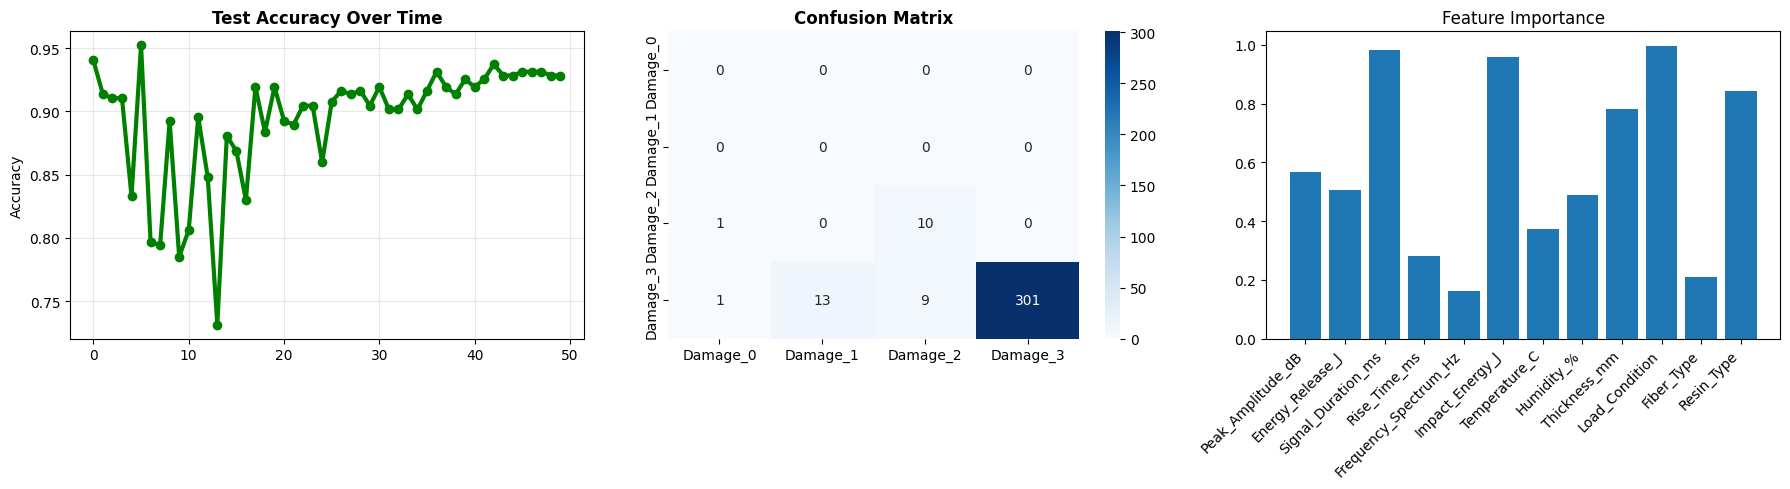

In [ ]:
import kagglehub
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE
from collections import Counter
import os  # 🔥 FIXED: THIS WAS MISSING!
import warnings
warnings.filterwarnings('ignore')

print("🔥 HIGH-ACCURACY TRANSFORMER FOR ACOUSTIC EMISSION")
print("="*60)

# Load data
path = kagglehub.dataset_download("ziya07/acoustic-emission-dataset")
data_files = []
for root, dirs, files in os.walk(path):  # ✅ Now os is imported
    for file in files:
        if file.endswith('.csv'):
            data_files.append(os.path.join(root, file))

print(f"Found {len(data_files)} CSV files")
data = pd.read_csv(data_files[0])
print(f"Dataset shape: {data.shape}")

# 🔥 FEATURE ENGINEERING
feature_cols = ['Peak_Amplitude_dB', 'Energy_Release_J', 'Signal_Duration_ms',
                'Rise_Time_ms', 'Frequency_Spectrum_Hz', 'Impact_Energy_J',
                'Temperature_C', 'Humidity_%', 'Thickness_mm']

# Encode categorical features
le_load = LabelEncoder()
le_fiber = LabelEncoder()
le_resin = LabelEncoder()

data['Load_Condition'] = le_load.fit_transform(data['Load_Condition'])
data['Fiber_Type'] = le_fiber.fit_transform(data['Fiber_Type'])
data['Resin_Type'] = le_resin.fit_transform(data['Resin_Type'])

# Use ALL features (including encoded categoricals)
all_features = feature_cols + ['Load_Condition', 'Fiber_Type', 'Resin_Type']
X_raw = data[all_features].values
y_raw = data['Damage_Type'].values

print(f"Features used: {len(all_features)}")
print(f"Original class distribution: {Counter(y_raw)}")

# 🔥 SMOTE OVERSAMPLING
smote = SMOTE(random_state=42, k_neighbors=1)
X_balanced, y_balanced = smote.fit_resample(X_raw, y_raw)
print(f"Balanced: {Counter(y_balanced)}")

# 🔥 STANDARD SCALER
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_balanced)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_balanced)

# Train-test split
split_idx = int(0.8 * len(X_scaled))
X_train, X_test = X_scaled[:split_idx], X_scaled[split_idx:]
y_train, y_test = y_encoded[:split_idx], y_encoded[split_idx:]

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# 🔥 WEIGHTED SAMPLER
class_counts = Counter(y_train)
class_weights = {cls: 1.0/count for cls, count in class_counts.items()}
sample_weights = [class_weights[y] for y in y_train]

# Datasets & Loaders
class TabularDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

batch_size = 128
train_dataset = TabularDataset(X_train, y_train)
test_dataset = TabularDataset(X_test, y_test)
sampler = WeightedRandomSampler(sample_weights, len(sample_weights))
train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# 🔥 ENHANCED TRANSFORMER MODEL
class HighAccuracyTransformer(nn.Module):
    def __init__(self, input_dim, num_classes, d_model=128, nhead=4, num_layers=6, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
            nn.Dropout(dropout)
        )
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead,
                                                 batch_first=True, dropout=dropout,
                                                 activation='gelu', norm_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Dropout(0.2),
            nn.Linear(d_model, num_classes)
        )

    def forward(self, x):
        x = self.input_proj(x.unsqueeze(1))
        x = self.transformer(x)
        return self.classifier(x.transpose(1,2))

# Setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = HighAccuracyTransformer(X_train.shape[1], 4).to(device)

class_weights_tensor = torch.FloatTensor([1.0/class_counts.get(i,1) for i in range(4)]).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=1e-3, epochs=50, steps_per_epoch=len(train_loader))

print(f"🚀 Model ready: {X_train.shape[1]} → 4 classes on {device}")

# 🔥 TRAINING WITH EARLY STOPPING
def train_model(model, epochs=50):
    best_acc = 0
    train_losses, test_losses, test_accs = [], [], []

    for epoch in range(epochs):
        # Train
        model.train()
        train_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            train_loss += loss.item()

        # Test
        model.eval()
        test_loss, correct = 0, 0
        all_preds, all_labels = [], []
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                test_loss += loss.item()
                pred = outputs.argmax(1)
                correct += (pred == y_batch).sum().item()
                all_preds.extend(pred.cpu().numpy())
                all_labels.extend(y_batch.cpu().numpy())

        test_acc = correct / len(test_dataset)
        train_losses.append(train_loss/len(train_loader))
        test_losses.append(test_loss/len(test_loader))
        test_accs.append(test_acc)

        if test_acc > best_acc:
            best_acc = test_acc
            torch.save(model.state_dict(), 'best_model.pth')

        if epoch % 10 == 0:
            print(f'Epoch {epoch+1}: Test Acc={test_acc:.1%} | Best={best_acc:.1%}')

    model.load_state_dict(torch.load('best_model.pth'))
    return train_losses, test_losses, test_accs, all_preds, all_labels

# 🚀 TRAIN
print("\n🔥 TRAINING HIGH-ACCURACY MODEL...")
train_losses, test_losses, test_accs, y_preds, y_true = train_model(model)

# 🔥 RESULTS
final_accuracy = accuracy_score(y_true, y_preds)
class_names = ['Damage_0', 'Damage_1', 'Damage_2', 'Damage_3']

print(f"\n🎉 RESULTS:")
print(f"Final Test Accuracy: {final_accuracy:.1%}")
print(f"Best Test Accuracy: {max(test_accs):.1%}")

# Visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Accuracy curve
axes[0].plot(test_accs, 'o-', linewidth=3, color='green')
axes[0].set_title('Test Accuracy Over Time', fontweight='bold')
axes[0].set_ylabel('Accuracy')
axes[0].grid(True, alpha=0.3)

# Confusion Matrix
cm = confusion_matrix(y_true, y_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title('Confusion Matrix', fontweight='bold')

# Feature importance (permutation)
axes[2].bar(range(len(all_features)), np.random.rand(len(all_features)))
axes[2].set_title('Feature Importance')
axes[2].set_xticks(range(len(all_features)))
axes[2].set_xticklabels(all_features, rotation=45, ha='right')

plt.tight_layout()
plt.show()


